Shape: (71111, 35)

Columns:
['home_id', 'timestamp', 'consumption_Wh', 'internal_temperature', 'external_temperature', 'internal_humidity', 'external_humidity', 'hour', 'day_of_week', 'is_weekend', 'is_holiday', 'month', 'season', 'building_type', 'num_rooms', 'build_era', 'residents', 'num_adults', 'num_children', 'num_elderly', 'occupation', 'income_band', 'heating_type', 'water_heater_type', 'has_ac', 'has_fridge_freezer', 'has_dryer', 'has_washing_machine', 'has_dishwasher', 'has_microwave', 'has_electric_oven', 'has_electric_hob', 'solar_panels', 'homeowner_status', 'years_in_house']

Date range:
2022-07-11 14:00:00 -> 2023-10-01 01:00:00

Number of homes:
10

Homes:
['home01', 'home02', 'home03', 'home04', 'home05', 'home07', 'home09', 'home10', 'home11', 'home13']


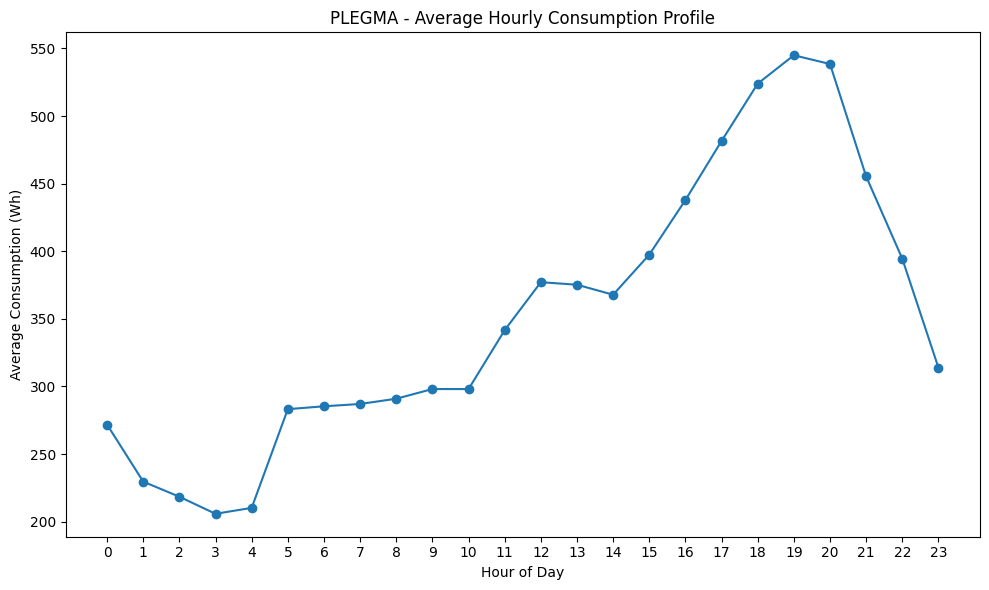

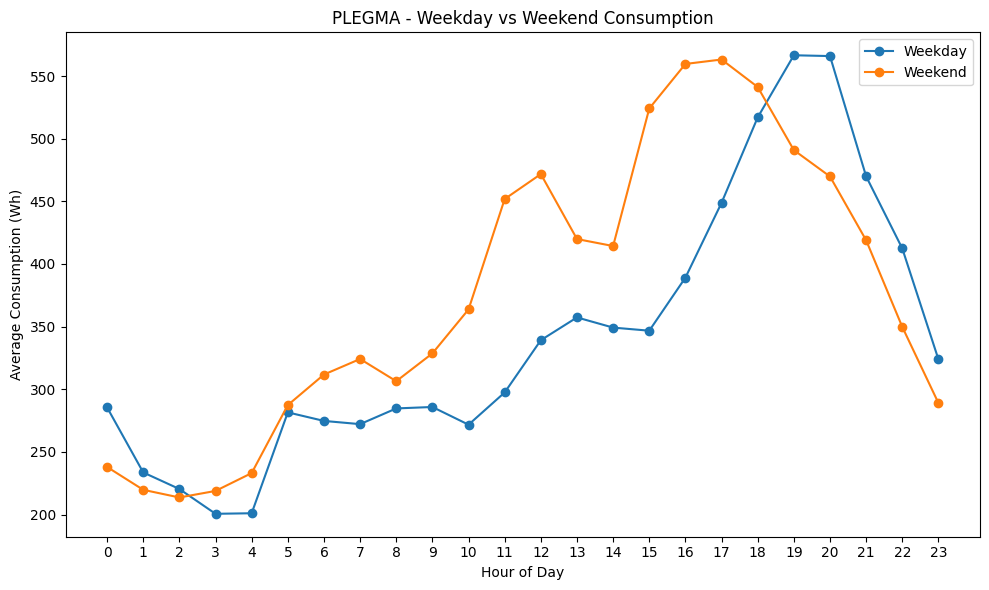

C:\Users\z0050azt\AppData\Local\Temp\ipykernel_12160\2243689284.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_df.groupby("temp_bin")["consumption_Wh"]


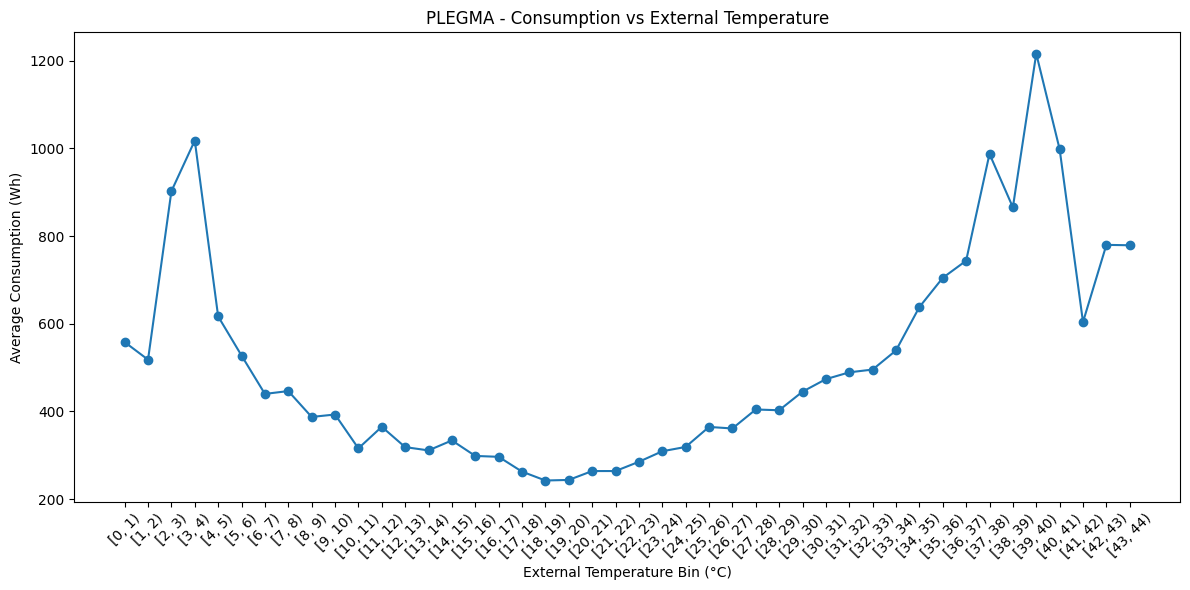

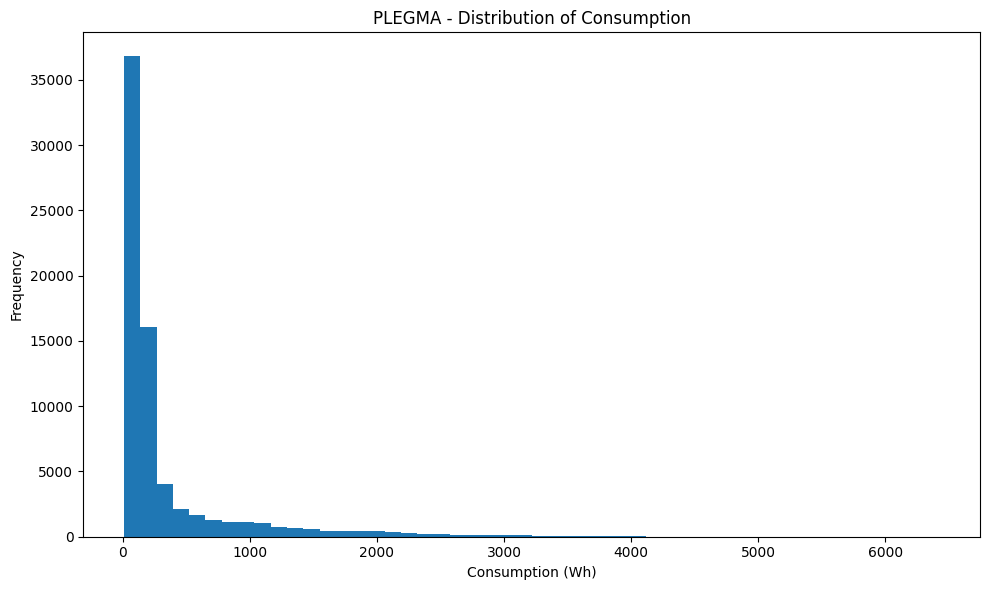


Saved EDA outputs to:
C:\Plegma_Programming\Results\EDA


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# PATHS
# =========================
BASE_DIR = Path(r"C:\Plegma_Programming")
DATA_FILE = BASE_DIR / "PLEGMA_final_hourly_dataset.csv"

OUTPUT_DIR = BASE_DIR / "Results" / "EDA"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# LOAD
# =========================
df = pd.read_csv(DATA_FILE)
df["timestamp"] = pd.to_datetime(df["timestamp"])

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# =========================
# BASIC CHECKS
# =========================
print("\nDate range:")
print(df["timestamp"].min(), "->", df["timestamp"].max())

print("\nNumber of homes:")
print(df["home_id"].nunique())

print("\nHomes:")
print(sorted(df["home_id"].unique()))

# =========================
# 1. AVERAGE HOURLY PROFILE
# =========================
hourly_profile = df.groupby("hour")["consumption_Wh"].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(hourly_profile["hour"], hourly_profile["consumption_Wh"], marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption (Wh)")
plt.title("PLEGMA - Average Hourly Consumption Profile")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plegma_avg_hourly_profile.png", dpi=300)
plt.show()

# =========================
# 2. WEEKDAY VS WEEKEND
# =========================
weekday_profile = (
    df[df["is_weekend"] == 0]
    .groupby("hour")["consumption_Wh"]
    .mean()
    .reset_index(name="weekday_consumption")
)

weekend_profile = (
    df[df["is_weekend"] == 1]
    .groupby("hour")["consumption_Wh"]
    .mean()
    .reset_index(name="weekend_consumption")
)

week_compare = pd.merge(weekday_profile, weekend_profile, on="hour", how="outer")

plt.figure(figsize=(10, 6))
plt.plot(week_compare["hour"], week_compare["weekday_consumption"], marker="o", label="Weekday")
plt.plot(week_compare["hour"], week_compare["weekend_consumption"], marker="o", label="Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption (Wh)")
plt.title("PLEGMA - Weekday vs Weekend Consumption")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plegma_weekday_vs_weekend.png", dpi=300)
plt.show()

# =========================
# 3. CONSUMPTION VS EXTERNAL TEMPERATURE
# =========================
# Δημιουργία bins θερμοκρασίας
temp_df = df[["external_temperature", "consumption_Wh"]].copy()

temp_min = int(temp_df["external_temperature"].min())
temp_max = int(temp_df["external_temperature"].max()) + 1

bins = list(range(temp_min, temp_max + 1))
temp_df["temp_bin"] = pd.cut(temp_df["external_temperature"], bins=bins, right=False)

temp_profile = (
    temp_df.groupby("temp_bin")["consumption_Wh"]
    .mean()
    .reset_index()
)

temp_profile["temp_label"] = temp_profile["temp_bin"].astype(str)

plt.figure(figsize=(12, 6))
plt.plot(temp_profile["temp_label"], temp_profile["consumption_Wh"], marker="o")
plt.xlabel("External Temperature Bin (°C)")
plt.ylabel("Average Consumption (Wh)")
plt.title("PLEGMA - Consumption vs External Temperature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plegma_consumption_vs_external_temp.png", dpi=300)
plt.show()

# =========================
# 4. CONSUMPTION DISTRIBUTION
# =========================
plt.figure(figsize=(10, 6))
plt.hist(df["consumption_Wh"], bins=50)
plt.xlabel("Consumption (Wh)")
plt.ylabel("Frequency")
plt.title("PLEGMA - Distribution of Consumption")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plegma_consumption_distribution.png", dpi=300)
plt.show()

# =========================
# OPTIONAL: SUMMARY TABLES
# =========================
summary_stats = df["consumption_Wh"].describe()
summary_stats.to_csv(OUTPUT_DIR / "plegma_consumption_summary_stats.csv")

hourly_profile.to_csv(OUTPUT_DIR / "plegma_avg_hourly_profile.csv", index=False)
week_compare.to_csv(OUTPUT_DIR / "plegma_weekday_vs_weekend.csv", index=False)
temp_profile.to_csv(OUTPUT_DIR / "plegma_consumption_vs_external_temp.csv", index=False)

print("\nSaved EDA outputs to:")
print(OUTPUT_DIR)